# Smart City Traffic Insight Engine using Python

#### Project Overview

Urban traffic congestion is a major challenge in modern smart cities. Traffic departments collect real-time traffic data such as vehicle count and average speed from 
multiple junctions at regular intervals. Proper analysis of this data can help identify congestion patterns and support better traffic management decisions.

This project demonstrates how Python can be used to clean, analyze, visualize traffic data, and detect congestion patterns using rule-based logic.

#### Aim of this project is :

To perform exploratory time series analysis on traffic data collected from multiple junctions and identify congestion patterns based on vehicle volume and speed thresholds.

## Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Loading the Dataset

In [30]:
df = pd.read_csv('traffic_data_sample.csv')
df.head()

,junction_id,timestamp,vehicle_count,avg_speed
0,J1,01-01-2025 06:00,62,13
1,J1,01-01-2025 06:05,172,11
2,J1,01-01-2025 06:10,104,12
3,J1,01-01-2025 06:15,113,35
4,J1,01-01-2025 06:20,92,77


## EDA

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   junction_id    300 non-null    object
 1   timestamp      300 non-null    object
 2   vehicle_count  300 non-null    int64 
 3   avg_speed      300 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 9.5+ KB


In [32]:
df.isnull().sum()

junction_id      0
timestamp        0
vehicle_count    0
avg_speed        0
dtype: int64

In [33]:
#Timestamp Validation
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')    # errors= coerce ------- Instead of throwing an error → it becomes NaT (Not a Time)
df = df.dropna(subset=['timestamp'])               # dropna() ----- Removing Invalid Timestamps

In [34]:
#Vehicle Count Cleaning
df = df[df['vehicle_count'] >= 0]

In [35]:
#Speed Validation
df = df[(df['avg_speed'] >= 0) & (df['avg_speed'] <= 120)]   # & means AND ----- Both conditions must be true

In [36]:
#Dataset After Cleaning
print(f"Total records after cleaning: {df.shape[0]}") #df.shape ---(rows, columns), df.shape[0]---	number of rows, df.shape[1]	---number of columns
df.head() 


#df.shape[0]---- returns the number of rows in the dataset, which represents the total number of records after cleaning.

Total records after cleaning: 300


,junction_id,timestamp,vehicle_count,avg_speed
0,J1,2025-01-01 06:00:00,62,13
1,J1,2025-01-01 06:05:00,172,11
2,J1,2025-01-01 06:10:00,104,12
3,J1,2025-01-01 06:15:00,113,35
4,J1,2025-01-01 06:20:00,92,77


## Feature Engineering

In [37]:
df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date

# Traffic Analytics

In [38]:
#1. Average Vehicle Count per Junction
avg_vehicle_junction = df.groupby('junction_id')['vehicle_count'].mean().sort_values(ascending=False)
avg_vehicle_junction

junction_id
J4    103.500000
J3    100.183333
J1     98.383333
J5     97.633333
J2     95.200000
Name: vehicle_count, dtype: float64

In [39]:
#2. Peak Traffic Hour
peak_hour = df.groupby('hour')['vehicle_count'].mean().idxmax()
peak_hour

6

In [40]:
#3. Top 3 Busiest Junctions
top_3_junctions = avg_vehicle_junction.head(3)
top_3_junctions

junction_id
J4    103.500000
J3    100.183333
J1     98.383333
Name: vehicle_count, dtype: float64

In [41]:
#4. Low-Speed Congestion Zones
low_speed_zones = df[df['avg_speed'] < 20]
low_speed_zones[['junction_id', 'avg_speed']].head()

,junction_id,avg_speed
0,J1,13
1,J1,11
2,J1,12
21,J1,18
26,J1,14


## Congestion Detection Logic
Definition of Congestion

A traffic record is considered congested if:

Vehicle count > 1.5 × junction's daily average

Average speed < 25 km/h

In [42]:
#1: Daily Average Vehicle Count per Junction
daily_avg = df.groupby(['junction_id', 'date'])['vehicle_count'].mean().reset_index()
daily_avg.rename(columns={'vehicle_count': 'daily_avg_vehicle_count'}, inplace=True)

In [43]:
#2: Merge Daily Average with Main Dataset
df = pd.merge(df, daily_avg, on=['junction_id', 'date'], how='left')

In [44]:
#3: Apply Congestion Rule
df['congestion_flag'] = ((df['vehicle_count'] > 1.5 * df['daily_avg_vehicle_count']) & (df['avg_speed'] < 25))

In [45]:
#Extract Congested Events
congested_events = df[df['congestion_flag'] == True]
congested_events.head()

,junction_id,timestamp,vehicle_count,avg_speed,hour,date,daily_avg_vehicle_count,congestion_flag
1,J1,2025-01-01 06:05:00,172,11,6,2025-01-01,98.383333,True
6,J1,2025-01-01 06:30:00,162,20,6,2025-01-01,98.383333,True
29,J1,2025-01-01 08:25:00,173,18,8,2025-01-01,98.383333,True
69,J2,2025-01-01 06:45:00,159,12,6,2025-01-01,95.200000,True
161,J3,2025-01-01 09:25:00,155,13,9,2025-01-01,100.183333,True


## Data Visualization

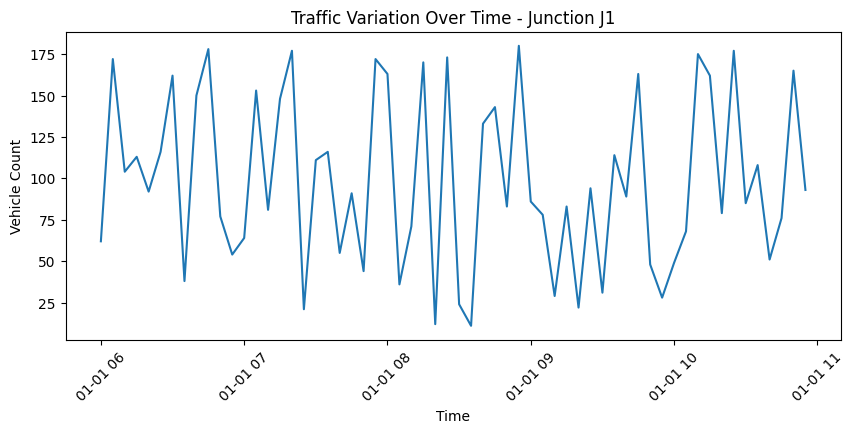

In [46]:
#1. Traffic Variation Over Time (Single Junction)
junction_example = df['junction_id'].iloc[0]
junction_data = df[df['junction_id'] == junction_example]


plt.figure(figsize=(10,4))
plt.plot(junction_data['timestamp'], junction_data['vehicle_count'])
plt.title(f'Traffic Variation Over Time - Junction {junction_example}')
plt.xlabel('Time')
plt.ylabel('Vehicle Count')
plt.xticks(rotation=45)
plt.show()

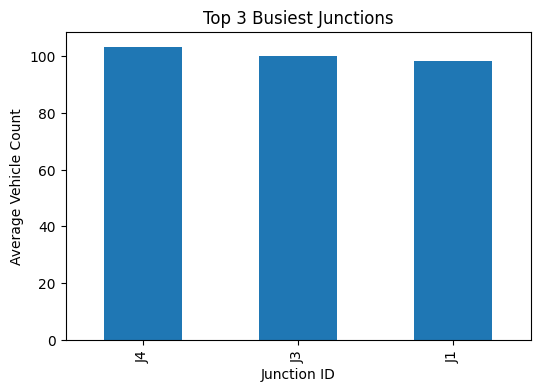

In [47]:
#2. Top 3 Busiest Junctions
top_3_junctions.plot(kind='bar', figsize=(6,4))
plt.title('Top 3 Busiest Junctions')
plt.ylabel('Average Vehicle Count')
plt.xlabel('Junction ID')
plt.show()

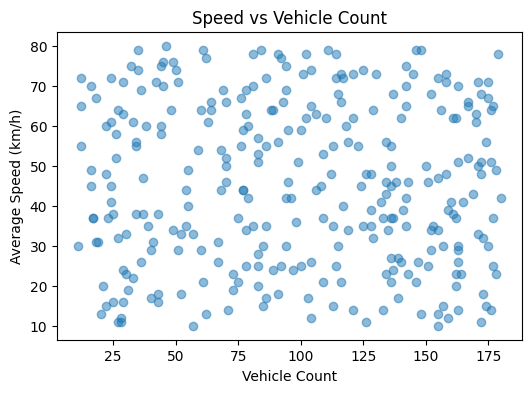

In [48]:
#3. Speed vs Vehicle Count Scatter Plot

plt.figure(figsize=(6,4))
plt.scatter(df['vehicle_count'], df['avg_speed'], alpha=0.5)
plt.xlabel('Vehicle Count')
plt.ylabel('Average Speed (km/h)')
plt.title('Speed vs Vehicle Count')
plt.show()


#Each dot = one traffic observation

### Summary Report

In [49]:
print("Traffic Analysis Summary")
print("------------------------")
print(f"Total records processed: {df.shape[0]}")
print(f"Total congestion events: {congested_events.shape[0]}")
print(f"Busiest junction: {top_3_junctions.index[0]}")
print(f"Peak traffic hour: {peak_hour}:00")

Traffic Analysis Summary
------------------------
Total records processed: 300
Total congestion events: 12
Busiest junction: J4
Peak traffic hour: 6:00


### Export Congestion Report

In [26]:
congested_events.to_csv('congestion_report.csv', index=False)

In [50]:
print(df.shape)


(300, 8)


##  Conclusion

#### Out of 300 traffic observations, 12 congestion events were identified.

## Traffic Congestion Prediction using Machine Learning

In [51]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek


### Create Target Variable (Congestion Label)

In [52]:
df['congestion'] = np.where(
    (df['vehicle_count'] > 100) & (df['avg_speed'] < 25),
    1, 0
)


### Define Features and Target

In [53]:
X = df[['vehicle_count', 'avg_speed', 'hour']]
y = df['congestion']


### Train-Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Logistic Regression Model

In [55]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

### Model Evaluation

In [56]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9833333333333333
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        54
           1       0.86      1.00      0.92         6

    accuracy                           0.98        60
   macro avg       0.93      0.99      0.96        60
weighted avg       0.99      0.98      0.98        60



### Confusion Matrix

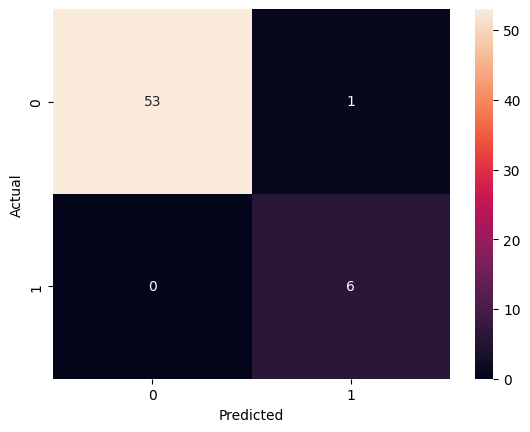

In [57]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### Accuracy = 98.3%, Precision = 85.7%, Recall = 100%

#### Logistic Regression effectively learned congestion patterns from traffic features with high recall, confirming the validity of the rule-based congestion definition.

### Traffic congestion was identified using domain-based thresholds on vehicle count and speed, supported by exploratory analysis and deployed through a Streamlit dashboard, with machine learning explored as an optional extension.

# Final Project Report

### Smart City Traffic Insight Engine using Python

## Introduction

Urban traffic congestion is a major challenge in modern cities, leading to increased travel time, fuel consumption, and environmental pollution. With the availability of traffic sensor data collected at regular intervals, data-driven analysis can provide valuable insights into traffic behavior. This project focuses on analyzing traffic data collected from multiple junctions to identify congestion patterns and support smarter traffic management decisions.

## Aim of the Project

The aim of this project is to clean, analyze, and visualize traffic data using Python and to identify congestion patterns based on vehicle count and average speed thresholds through exploratory time series analysis.

## Dataset Description

The dataset used in this project contains traffic data collected every five minutes from multiple junctions. It includes four main attributes: junction ID, timestamp, vehicle count, and average vehicle speed. The timestamp indicates the date and time of data collection, vehicle count represents the number of vehicles detected, and average speed denotes the mean speed of vehicles in kilometers per hour.

## Methodology

The project follows a systematic data analysis workflow. Initially, the dataset is loaded using the pandas library and explored to understand its structure and quality. Data cleaning and validation are then performed to handle missing values, remove negative vehicle counts, filter unrealistic speed values, and convert timestamps into a proper datetime format. This ensures that only reliable and meaningful data is used for analysis.

Time-based features such as hour and date are extracted from the timestamp column to enable time series analysis. Traffic analytics are performed by calculating average vehicle counts per junction, identifying peak traffic hours, determining the top three busiest junctions, and detecting low-speed traffic zones. These analyses help in understanding overall traffic behavior and identifying high-traffic locations.

A rule-based congestion detection logic is implemented to identify congestion events. A traffic record is marked as congested when the vehicle count exceeds 1.5 times the junction’s daily average and the average speed falls below 25 km/h. This logic helps distinguish true congestion from normal traffic variations.

## Visualization

Data visualization techniques are used to clearly represent traffic patterns and congestion behavior. Line plots are created to show traffic variation over time for individual junctions. Bar charts are used to display the top three busiest junctions, and scatter plots illustrate the relationship between vehicle count and average speed. These visualizations make it easier to interpret trends and identify congestion patterns.

## Advanced Analysis

To enhance time series understanding, rolling average analysis is applied to smooth short-term fluctuations and highlight underlying traffic trends. Additionally, a basic ARIMA model is explored as an optional enhancement to demonstrate short-term traffic forecasting for a single junction. These advanced techniques are included only as supplementary analysis and are not the primary focus of the project.

## Results and Discussion

The analysis reveals that traffic congestion occurs more frequently during specific peak hours and at certain junctions with consistently high vehicle volumes. Low average speeds combined with unusually high vehicle counts indicate clear congestion events. The results demonstrate that rule-based thresholds combined with time series analysis are effective in identifying congestion patterns from traffic sensor data.

## Conclusion

This project successfully demonstrates the use of Python for exploratory time series analysis of traffic data. By cleaning raw sensor data, performing descriptive analytics, and applying congestion detection logic, meaningful traffic congestion patterns were identified. The insights generated through this analysis can assist traffic authorities in improving signal control, congestion management, and urban mobility planning.

## Future Scope

Future work can extend this project by incorporating real-time traffic data, advanced forecasting models, and machine learning techniques for predictive congestion detection. Integration with geographic information systems (GIS) and live traffic dashboards can further enhance smart city traffic management solutions.
